# Light weight version of the grid search

In [1]:
!pip install numpy pandas scikit-learn torch torchvision tqdm liac-arff

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.1 MB/s eta 0:00:00
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11716 sha256=2b0d3ffb7a3acba2f340500cf2ce5630734769fbf467c8b7254d651217be4a8b
  Stor

In [ ]:
### Imports
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import arff  # from the liac-arff library
import random
from tqdm.auto import tqdm
from itertools import product
import warnings

warnings.filterwarnings('ignore')

In [ ]:

### Data Loading and Preprocessing
adult_arff_file = "adult.arff"

# Load ARFF file
with open(adult_arff_file, 'r') as f:
    dataset = arff.load(f)

data = pd.DataFrame(dataset["data"], columns=[attr[0] for attr in dataset["attributes"]])

# Identify continuous and categorical columns
continuous_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
target_col = "income"

# Preprocess data
data.replace("?", np.nan, inplace=True)
data.dropna(inplace=True)
labels = data[target_col].values
data.drop(columns=[target_col], inplace=True)

cat_cols = [c for c in data.columns if c not in continuous_cols]

# One-hot encode categorical columns
ohe = OneHotEncoder(sparse_output=False, drop='first')
cat_data = ohe.fit_transform(data[cat_cols])
ohe_feature_names = ohe.get_feature_names_out(cat_cols)

# Scale continuous columns
scaler = StandardScaler()
cont_data = scaler.fit_transform(data[continuous_cols])

# Combine features
X = np.hstack([cont_data, cat_data])
feature_names = continuous_cols + list(ohe_feature_names)
X_df = pd.DataFrame(X, columns=feature_names)

# Convert labels to binary
y = np.array([0 if val.strip() == "<=50K" else 1 for val in labels])

def build_categorical_group_dict(ohe, cat_cols, n_cont):
    """
    ohe: trained OneHotEncoder
    cat_cols: list of original categorical column names
    n_cont: how many continuous columns in your final X
    returns: a dict, e.g. { 'marital-status': (start_idx, end_idx), ... }
    """
    cat_group_dict = {}
    offset = n_cont  # The index where categorical columns start in X

    # ohe.categories_ is a list of arrays, one per categorical feature
    # Because drop='first', each feature i has len(ohe.categories_[i]) - 1 columns in X
    for i, col_name in enumerate(cat_cols):
        group_size = len(ohe.categories_[i]) - 1
        cat_group_dict[col_name] = (offset, offset + group_size)
        offset += group_size

    return cat_group_dict

n_cont = len(continuous_cols)
cat_group_dict = build_categorical_group_dict(ohe, cat_cols, n_cont)



def post_process_one_hot(X_synth, cat_group_dict):
    """
    Converts fractional one-hot columns into discrete one-hot columns.
    For each group (feature), picks the index of the maximum value and sets it to 1.
    All other positions in that group are 0.

    X_synth: numpy array of shape [n_samples, n_features] (raw generator output)
    cat_group_dict: dictionary { feature_name: (start_idx, end_idx), ... }
    """
    X_synth_post = X_synth.copy()  # avoid modifying in-place

    for cat_name, (start, end) in cat_group_dict.items():
        group_slice = X_synth_post[:, start:end]
        # For each row, find which column in this group is largest
        argmax_indices = np.argmax(group_slice, axis=1)

        # Zero out the entire group
        X_synth_post[:, start:end] = 0.0

        # Set exactly one column to 1 for each row
        for row_idx, col_idx in enumerate(argmax_indices):
            X_synth_post[row_idx, start + col_idx] = 1.0

    return X_synth_post


# Train/test split
def get_data_splits(random_seed):
    """
    Splits the dataset into training and testing sets using an 80/20 stratified split.
    """
    return train_test_split(X, y, test_size=0.2, random_state=random_seed, stratify=y)

class Generator(nn.Module):
    """
    Generator network for a standard (unconditional) GAN.
    """

    def __init__(self, noise_dim, output_dim, hidden_dims=[128], dropout_rate=0.0, batch_norm=False):
        """
        Parameters:
            noise_dim (int): Dimension of the random noise input.
            output_dim (int): Dimension of the generated sample.
            hidden_dims (list): List specifying the number of units in each hidden layer.
            dropout_rate (float): Dropout rate (if > 0, dropout is applied).
            batch_norm (bool): Whether to apply batch normalization after linear layers.
        """

        super(Generator, self).__init__()
        layers = []
        in_dim = noise_dim

        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            in_dim = h_dim

        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        """
        Forward pass for the generator.
        """

        return self.net(z)

class Discriminator(nn.Module):
    """
    Discriminator network for a standard (unconditional) GAN.
    """

    def __init__(self, input_dim, hidden_dims=[128], dropout_rate=0.0, batch_norm=False):
        """
        Parameters:
            input_dim (int): Dimension of the input sample.
            hidden_dims (list): List specifying the number of units in each hidden layer.
            dropout_rate (float): Dropout rate (if > 0, dropout is applied).
            batch_norm (bool): Whether to apply batch normalization after linear layers.
        """
        super(Discriminator, self).__init__()
        layers = []
        in_dim = input_dim

        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.LeakyReLU(0.2))
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            in_dim = h_dim

        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        """
        Forward pass for the discriminator.
        """
        return self.net(x)

def train_gan(X_train, noise_dim=32, batch_size=128, lr=1e-4, n_epochs=50,
              hidden_dims=[128], dropout_rate=0.0, batch_norm=False, device='cpu'):
    """
    Trains a standard (unconditional) GAN on the provided training data.

    Parameters:
        X_train (np.array): Real training data.
        noise_dim (int): Dimension of the random noise vector input to the generator.
        batch_size (int): Batch size for training.
        lr (float): Learning rate for the generator (the discriminator uses lr * 0.1).
        n_epochs (int): Number of training epochs.
        hidden_dims (list): List specifying the number of units in each hidden layer.
        dropout_rate (float): Dropout rate for regularization.
        batch_norm (bool): Whether to use batch normalization.
        device (str): Device to use ('cpu' or 'cuda').

    Returns:
        tuple: (G, D, G_losses, D_losses) where G and D are the trained generator
               and discriminator models, and G_losses and D_losses are lists of loss values.
    """

    train_dataset = TabularDataset(X_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    data_dim = X_train.shape[1]

    G = Generator(noise_dim=noise_dim, output_dim=data_dim, hidden_dims=hidden_dims,
                  dropout_rate=dropout_rate, batch_norm=batch_norm).to(device)
    D = Discriminator(input_dim=data_dim, hidden_dims=hidden_dims,
                      dropout_rate=dropout_rate, batch_norm=batch_norm).to(device)

    criterion = nn.BCEWithLogitsLoss()

    # Use separate learning rates for G and D
    optim_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    optim_D = optim.Adam(D.parameters(), lr=lr * 0.1, betas=(0.5, 0.999))

    G_losses = []
    D_losses = []

    for epoch in range(n_epochs):
        g_loss_epoch = 0.0
        d_loss_epoch = 0.0

        for real_batch in train_loader:
            real_batch = real_batch.to(device)
            batch_size_cur = real_batch.size(0)

            # Soft labels for stability:
            real_labels = torch.full((batch_size_cur, 1), 0.9, device=device)
            fake_labels = torch.full((batch_size_cur, 1), 0.1, device=device)

            # Train Discriminator on real data
            D_real = D(real_batch)
            d_loss_real = criterion(D_real, real_labels)

            # Generate fake data and compute loss for discriminator
            z = torch.randn(batch_size_cur, noise_dim).to(device)
            fake_batch = G(z)
            D_fake = D(fake_batch.detach())
            d_loss_fake = criterion(D_fake, fake_labels)

            d_loss = d_loss_real + d_loss_fake

            optim_D.zero_grad()
            d_loss.backward()
            optim_D.step()

            # Train Generator to fool the discriminator
            D_fake_for_G = D(fake_batch)
            g_loss = criterion(D_fake_for_G, real_labels)

            optim_G.zero_grad()
            g_loss.backward()
            optim_G.step()

            g_loss_epoch += g_loss.item() * batch_size_cur
            d_loss_epoch += d_loss.item() * batch_size_cur

        G_losses.append(g_loss_epoch / len(train_loader.dataset))
        D_losses.append(d_loss_epoch / len(train_loader.dataset))

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{n_epochs}] | G Loss: {G_losses[-1]:.4f} | D Loss: {D_losses[-1]:.4f}")

    return G, D, G_losses, D_losses

class ConditionalGenerator(nn.Module):
    """
    Generator network for a conditional GAN (cGAN).
    """
    def __init__(self, noise_dim, label_dim, output_dim, hidden_dims=[128], dropout_rate=0.0, batch_norm=False):
        """
        Parameters:
            noise_dim (int): Dimension of the random noise input.
            label_dim (int): Dimension of the one-hot encoded label.
            output_dim (int): Dimension of the generated sample.
            hidden_dims (list): List specifying the number of units in each hidden layer.
            dropout_rate (float): Dropout rate (if > 0, dropout is applied).
            batch_norm (bool): Whether to apply batch normalization after linear layers.
        """

        super(ConditionalGenerator, self).__init__()
        in_dim = noise_dim + label_dim
        layers = []

        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            in_dim = h_dim

        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, z, labels):
        """
        Forward pass for the conditional generator.
        """

        x = torch.cat([z, labels], dim=1)
        return self.net(x)

class ConditionalDiscriminator(nn.Module):
    """
    Discriminator network for a conditional GAN (cGAN).
    """
    def __init__(self, input_dim, label_dim, hidden_dims=[128], dropout_rate=0.0, batch_norm=False):
        """
        Parameters:
            input_dim (int): Dimension of the input sample.
            label_dim (int): Dimension of the one-hot encoded label.
            hidden_dims (list): List specifying the number of units in each hidden layer.
            dropout_rate (float): Dropout rate (if > 0, dropout is applied).
            batch_norm (bool): Whether to apply batch normalization after linear layers.
        """
        super(ConditionalDiscriminator, self).__init__()
        in_dim = input_dim + label_dim
        layers = []

        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.LeakyReLU(0.2))
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            in_dim = h_dim

        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x, labels):
        """
        Forward pass for the conditional discriminator.
        """

        d_in = torch.cat([x, labels], dim=1)
        return self.net(d_in)

def train_cgan(X_train, y_train, noise_dim=32, batch_size=128, lr=1e-4, n_epochs=50,
               hidden_dims=[128], dropout_rate=0.0, batch_norm=False, device='cpu'):
    """
    Trains a conditional GAN (cGAN) on the provided training data.

    Parameters:
        X_train (np.array): Real training data.
        y_train (np.array): Labels corresponding to the training data.
        noise_dim (int): Dimension of the random noise vector input to the generator.
        batch_size (int): Batch size for training.
        lr (float): Learning rate for the generator (the discriminator uses lr * 0.1).
        n_epochs (int): Number of training epochs.
        hidden_dims (list): List specifying the number of units in each hidden layer.
        dropout_rate (float): Dropout rate for regularization.
        batch_norm (bool): Whether to use batch normalization.
        device (str): Device to use ('cpu' or 'cuda').

    Returns:
        tuple: (G, D, G_losses, D_losses) where G and D are the trained conditional generator
               and discriminator models, and G_losses and D_losses are lists of loss values.
    """

    num_classes = len(np.unique(y_train))
    y_oh = np.zeros((len(y_train), num_classes))
    y_oh[np.arange(len(y_train)), y_train] = 1
    y_oh = torch.FloatTensor(y_oh)

    class ConditionalTabularDataset(Dataset):
        """
        Dataset for conditional GAN training.
        """
        def __init__(self, X, Y_oh):
            self.X = torch.FloatTensor(X)
            self.Y_oh = Y_oh

        def __len__(self):
            return len(self.X)

        def __getitem__(self, idx):
            return self.X[idx], self.Y_oh[idx]

    train_dataset = ConditionalTabularDataset(X_train, y_oh)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    data_dim = X_train.shape[1]
    label_dim = num_classes

    G = ConditionalGenerator(noise_dim=noise_dim, label_dim=label_dim, output_dim=data_dim,
                             hidden_dims=hidden_dims, dropout_rate=dropout_rate, batch_norm=batch_norm).to(device)
    D = ConditionalDiscriminator(input_dim=data_dim, label_dim=label_dim,
                                 hidden_dims=hidden_dims, dropout_rate=dropout_rate, batch_norm=batch_norm).to(device)

    criterion = nn.BCEWithLogitsLoss()

    # Use separate learning rates for G and D
    optim_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    optim_D = optim.Adam(D.parameters(), lr=lr * 0.1, betas=(0.5, 0.999))

    G_losses = []
    D_losses = []

    for epoch in range(n_epochs):
        g_loss_epoch = 0.0
        d_loss_epoch = 0.0

        for real_batch, real_labels in train_loader:
            real_batch = real_batch.to(device)
            real_labels = real_labels.to(device)
            batch_size_cur = real_batch.size(0)

            # Soft targets for the discriminator:
            real_lbl = torch.full((batch_size_cur, 1), 0.9, device=device)
            fake_lbl = torch.full((batch_size_cur, 1), 0.1, device=device)

            # Train discriminator on real data
            D_real = D(real_batch, real_labels)
            d_loss_real = criterion(D_real, real_lbl)

            # Generate synthetic data
            z = torch.randn(batch_size_cur, noise_dim).to(device)
            fake_batch = G(z, real_labels)
            D_fake = D(fake_batch.detach(), real_labels)
            d_loss_fake = criterion(D_fake, fake_lbl)

            d_loss = d_loss_real + d_loss_fake

            optim_D.zero_grad()
            d_loss.backward()
            optim_D.step()

            # Train generator to fool discriminator
            D_fake_for_G = D(fake_batch, real_labels)
            g_loss = criterion(D_fake_for_G, real_lbl)

            optim_G.zero_grad()
            g_loss.backward()
            optim_G.step()

            g_loss_epoch += g_loss.item() * batch_size_cur
            d_loss_epoch += d_loss.item() * batch_size_cur

        G_losses.append(g_loss_epoch / len(train_loader.dataset))
        D_losses.append(d_loss_epoch / len(train_loader.dataset))

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{n_epochs}] | G Loss: {G_losses[-1]:.4f} | D Loss: {D_losses[-1]:.4f}")

    return G, D, G_losses, D_losses




class TabularDataset(Dataset):
    def __init__(self, data):
        self.data = torch.from_numpy(data).float()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]




def detection_metric(X_real, X_synth, n_splits=4, random_state=42):
    """
    Returns average AUC from a 4-fold cross validation
    on a 50/50 real/synthetic dataset.
    """
    # Label real=0, synth=1
    y_real = np.zeros(len(X_real), dtype=int)
    y_synth = np.ones(len(X_synth), dtype=int)

    X_combined = np.vstack([X_real, X_synth])
    y_combined = np.concatenate([y_real, y_synth])

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    aucs = []
    for train_idx, test_idx in skf.split(X_combined, y_combined):
        X_train_fold, X_test_fold = X_combined[train_idx], X_combined[test_idx]
        y_train_fold, y_test_fold = y_combined[train_idx], y_combined[test_idx]

        clf = RandomForestClassifier(n_estimators=100, random_state=random_state)
        clf.fit(X_train_fold, y_train_fold)

        y_proba = clf.predict_proba(X_test_fold)[:,1]
        auc_val = roc_auc_score(y_test_fold, y_proba)
        aucs.append(auc_val)

    return np.mean(aucs)


def efficacy_metric(X_train, y_train, X_test, y_test, X_synth, y_synth, random_state=42):
    """
Evaluates the efficacy of synthetic data as a substitute for real data by comparing the AUC scores
of a model trained on real data versus a model trained on synthetic data.
"""
# Train on real data
    clf_real = RandomForestClassifier(n_estimators=100, random_state=random_state)
    clf_real.fit(X_train, y_train)
    y_proba_real = clf_real.predict_proba(X_test)[:, 1]
    auc_real = roc_auc_score(y_test, y_proba_real)

    # Train on synthetic data
    clf_synth = RandomForestClassifier(n_estimators=100, random_state=random_state)
    clf_synth.fit(X_synth, y_synth)
    y_proba_synth = clf_synth.predict_proba(X_test)[:, 1]
    auc_synth = roc_auc_score(y_test, y_proba_synth)

    ratio = auc_synth / auc_real if auc_real > 0 else 0

    return auc_real, auc_synth, ratio


### Grid Search

def grid_search(hyperparameter_grid, seeds, X, y, device='cpu'):
    all_combinations = list(product(
        hyperparameter_grid['lr'],
        hyperparameter_grid['noise_dim'],
        hyperparameter_grid['hidden_dims'],
        hyperparameter_grid['batch_size'],
        hyperparameter_grid['dropout_rate'],
        hyperparameter_grid['batch_norm']
    ))

    results = []

    for (lr, noise_dim, hidden_dims, batch_size, dropout_rate, batch_norm) in all_combinations:
        for seed in seeds:
            print(f"\nTraining with seed={seed}, lr={lr}, noise_dim={noise_dim}, hidden_dims={hidden_dims}, "
                  f"batch_size={batch_size}, dropout_rate={dropout_rate}, batch_norm={batch_norm}")

            X_train, X_test, y_train, y_test = get_data_splits(seed)

            # Train Standard GAN
            print("\nGAN")
            G, D, G_losses, D_losses = train_gan(
                X_train=X_train,
                noise_dim=noise_dim,
                batch_size=batch_size,
                lr=lr,
                n_epochs=50,
                hidden_dims=hidden_dims,
                dropout_rate=dropout_rate,
                batch_norm=batch_norm,
                device=device
            )

            # Generate synthetic data for Standard GAN
            X_gan_synth = G(torch.randn(len(X_train), noise_dim).to(device)).detach().cpu().numpy()

            # fix discrete
            X_gan_synth_post = post_process_one_hot(X_gan_synth, cat_group_dict)

            # Evaluate Standard GAN
            det_auc_gan = detection_metric(X_train, X_gan_synth_post)
            auc_real_gan, auc_synth_gan, ratio_gan = efficacy_metric(
                X_train, y_train, X_test, y_test, X_gan_synth_post, np.random.choice(y_train, len(X_train))
            )

            print(f"GAN Detection AUC: {det_auc_gan:.4f}")
            print(f"GAN Efficacy: Real AUC = {auc_real_gan:.4f}, Synth AUC = {auc_synth_gan:.4f}, Ratio = {ratio_gan:.4f}")

            # Train Conditional GAN
            print("\ncGAN")
            G_c, D_c, G_c_losses, D_c_losses = train_cgan(
                X_train=X_train,
                y_train=y_train,
                noise_dim=noise_dim,
                batch_size=batch_size,
                lr=lr,
                n_epochs=50,
                hidden_dims=hidden_dims,
                dropout_rate=dropout_rate,
                batch_norm=batch_norm,
                device=device
            )

            # Generate synthetic data for Conditional GAN
            noise = torch.randn(len(X_train), noise_dim).to(device)  # Define noise
            labels_one_hot = torch.tensor(np.eye(len(np.unique(y_train)))[y_train], dtype=torch.float32).to(device)  # One-hot encode labels

            X_cgan_synth = G_c(noise, labels_one_hot).detach().cpu().numpy()

            # fix discrete
            X_cgan_synth_post = post_process_one_hot(X_cgan_synth, cat_group_dict)


            # Evaluate Conditional GAN
            det_auc_cgan = detection_metric(X_train, X_cgan_synth_post)
            auc_real_cgan, auc_synth_cgan, ratio_cgan = efficacy_metric(
                X_train, y_train, X_test, y_test, X_cgan_synth_post, y_train
            )

            print(f"CGAN Detection AUC: {det_auc_cgan:.4f}")
            print(f"CGAN Efficacy: Real AUC = {auc_real_cgan:.4f}, Synth AUC = {auc_synth_cgan:.4f}, Ratio = {ratio_cgan:.4f}")

            results.append({
                'seed': seed,
                'lr': lr,
                'noise_dim': noise_dim,
                'hidden_dims': hidden_dims,
                'batch_size': batch_size,
                'dropout_rate': dropout_rate,
                'batch_norm': batch_norm,
                'gan_det_auc': det_auc_gan,
                'gan_real_auc': auc_real_gan,
                'gan_synth_auc': auc_synth_gan,
                'gan_ratio': ratio_gan,
                'cgan_det_auc': det_auc_cgan,
                'cgan_real_auc': auc_real_cgan,
                'cgan_synth_auc': auc_synth_cgan,
                'cgan_ratio': ratio_cgan
            })

    return results

# Define hyperparameter grid
hyperparameter_grid = {
    'lr': [0.00001, 0.000001],
    'noise_dim': [32, 64],
    'hidden_dims': [[128, 128], [256, 256]],
    'batch_size': [128, 256],
    'dropout_rate': [0.0, 0.3],
    'batch_norm': [True, False],
}

# Perform grid search
device = 'cuda' if torch.cuda.is_available() else 'cpu'
seeds = [0, 54, 86]
results = grid_search(hyperparameter_grid, seeds, X, y, device=device)

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

In [ ]:
results_df.to_csv('grid_results.csv', index=False)

## training the GAN and cGAN with different seeds

Epoch [10/50] | G Loss: 1.1840 | D Loss: 0.9338
Epoch [20/50] | G Loss: 1.4944 | D Loss: 0.7848
Epoch [30/50] | G Loss: 1.6572 | D Loss: 0.7354
Epoch [40/50] | G Loss: 1.6796 | D Loss: 0.8086
Epoch [50/50] | G Loss: 1.6189 | D Loss: 0.9385


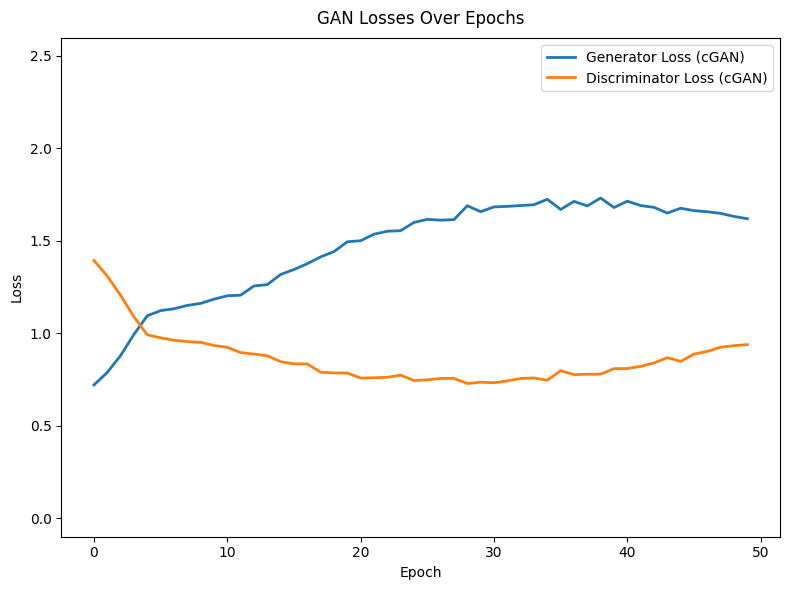

GAN Detection AUC: 1.0000
GAN Efficacy: Real AUC = 0.8947, Synth AUC = 0.4878, Ratio = 0.5452
Epoch [10/50] | G Loss: 1.0969 | D Loss: 1.0662
Epoch [20/50] | G Loss: 1.1949 | D Loss: 1.0207
Epoch [30/50] | G Loss: 1.2730 | D Loss: 1.0177
Epoch [40/50] | G Loss: 1.2653 | D Loss: 1.0467
Epoch [50/50] | G Loss: 1.2533 | D Loss: 1.0753


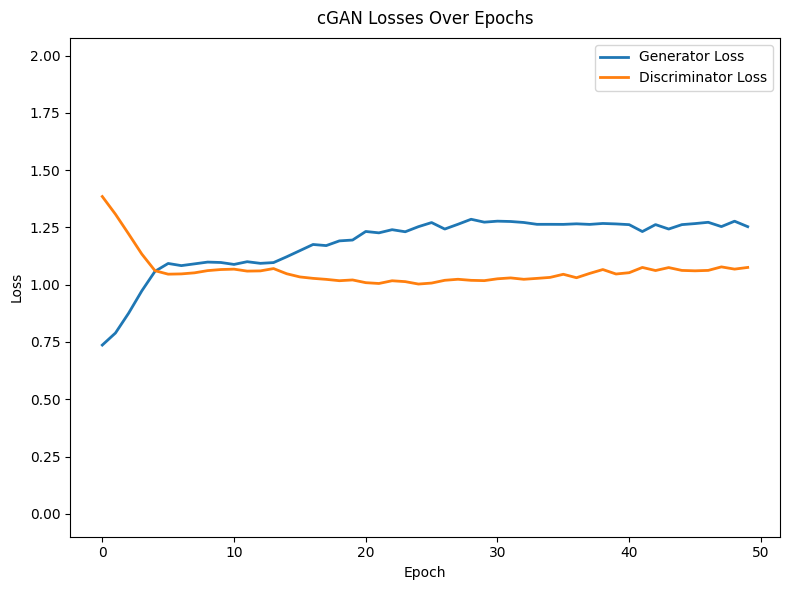

cGAN Detection AUC: 1.0000
cGAN Efficacy: Real AUC = 0.8947, Synth AUC = 0.8285, Ratio = 0.9260


In [26]:

import random
import matplotlib.pyplot as plt


# SET SEED
seed = 54
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = 'cuda' if torch.cuda.is_available() else 'cpu'


# TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = get_data_splits(random_seed=seed)


# TRAIN A STANDARD (UNCONDITIONAL) GAN
gan_lr = 0.00001
gan_noise_dim = 64
gan_hidden_dims = [128, 128]
gan_batch_size = 128
gan_dropout_rate = 0.3
gan_batch_norm = False
n_epochs = 50

G, D, G_losses, D_losses = train_gan(
    X_train=X_train,
    noise_dim=gan_noise_dim,
    batch_size=gan_batch_size,
    lr=gan_lr,
    n_epochs=n_epochs,
    hidden_dims=gan_hidden_dims,
    dropout_rate=gan_dropout_rate,
    batch_norm=gan_batch_norm,
    device=device
)


# PLOT GAN LOSSES
plt.figure(figsize=(8, 6))
plt.plot(range(n_epochs), G_losses, label='Generator Loss', linewidth=2)
plt.plot(range(n_epochs), D_losses, label='Discriminator Loss', linewidth=2)
plt.title('GAN Losses Over Epochs', fontsize=12, pad=10)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend(fontsize=10)

# Calculate appropriate y-axis limits
max_loss = max(max(G_losses), max(D_losses))
plt.ylim(-0.1, max_loss * 1.5)  # Extend y-axis range by 50%

# Make plot more compact
plt.tight_layout()
plt.show()


# GENERATE SYNTHETIC DATA AND EVALUATE
with torch.no_grad():
    z = torch.randn(len(X_train), gan_noise_dim).to(device)
    X_gan_synth = G(z).cpu().numpy()

y_gan_synth = np.random.choice(y_train, len(X_train))

det_auc_gan = detection_metric(X_train, X_gan_synth)
print(f"GAN Detection AUC: {det_auc_gan:.4f}")

auc_real_gan, auc_synth_gan, ratio_gan = efficacy_metric(
    X_train, y_train, X_test, y_test, X_gan_synth, y_gan_synth
)
print(f"GAN Efficacy: Real AUC = {auc_real_gan:.4f}, Synth AUC = {auc_synth_gan:.4f}, Ratio = {ratio_gan:.4f}")


# TRAIN A CONDITIONAL GAN (cGAN)
cgan_lr = 0.0001
cgan_noise_dim = 32
cgan_hidden_dims = [256, 256]
cgan_batch_size = 128
cgan_dropout_rate = 0.3
cgan_batch_norm = True

G_c, D_c, G_c_losses, D_c_losses = train_cgan(
    X_train=X_train,
    y_train=y_train,
    noise_dim=cgan_noise_dim,
    batch_size=cgan_batch_size,
    lr=cgan_lr,
    n_epochs=n_epochs,
    hidden_dims=cgan_hidden_dims,
    dropout_rate=cgan_dropout_rate,
    batch_norm=cgan_batch_norm,
    device=device
)


# PLOT cGAN LOSSES
plt.figure(figsize=(8, 6))
plt.plot(range(n_epochs), G_c_losses, label='Generator Loss (cGAN)', linewidth=2)
plt.plot(range(n_epochs), D_c_losses, label='Discriminator Loss (cGAN)', linewidth=2)
plt.title('cGAN Losses Over Epochs', fontsize=12, pad=10)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend(fontsize=10)

# Calculate appropriate y-axis limits
max_loss = max(max(G_c_losses), max(D_c_losses))
plt.ylim(-0.1, max_loss * 1.5)  # Extend y-axis range by 50%

# Make plot more compact
plt.tight_layout()
plt.show()


# GENERATE SYNTHETIC DATA (cGAN) AND EVALUATE
with torch.no_grad():
    num_classes = len(np.unique(y_train))
    y_train_oh = np.eye(num_classes)[y_train]
    y_train_oh_torch = torch.FloatTensor(y_train_oh).to(device)

    z_cgan = torch.randn(len(X_train), cgan_noise_dim).to(device)
    X_cgan_synth = G_c(z_cgan, y_train_oh_torch).cpu().numpy()

y_cgan_synth = y_train.copy()

det_auc_cgan = detection_metric(X_train, X_cgan_synth)
print(f"cGAN Detection AUC: {det_auc_cgan:.4f}")

auc_real_cgan, auc_synth_cgan, ratio_cgan = efficacy_metric(
    X_train, y_train, X_test, y_test, X_cgan_synth, y_cgan_synth
)
print(f"cGAN Efficacy: Real AUC = {auc_real_cgan:.4f}, Synth AUC = {auc_synth_cgan:.4f}, Ratio = {ratio_cgan:.4f}")


Epoch [10/50] | G Loss: 1.2360 | D Loss: 0.9067
Epoch [20/50] | G Loss: 1.5185 | D Loss: 0.7577
Epoch [30/50] | G Loss: 1.7038 | D Loss: 0.7349
Epoch [40/50] | G Loss: 1.6691 | D Loss: 0.8469
Epoch [50/50] | G Loss: 1.6655 | D Loss: 0.9092


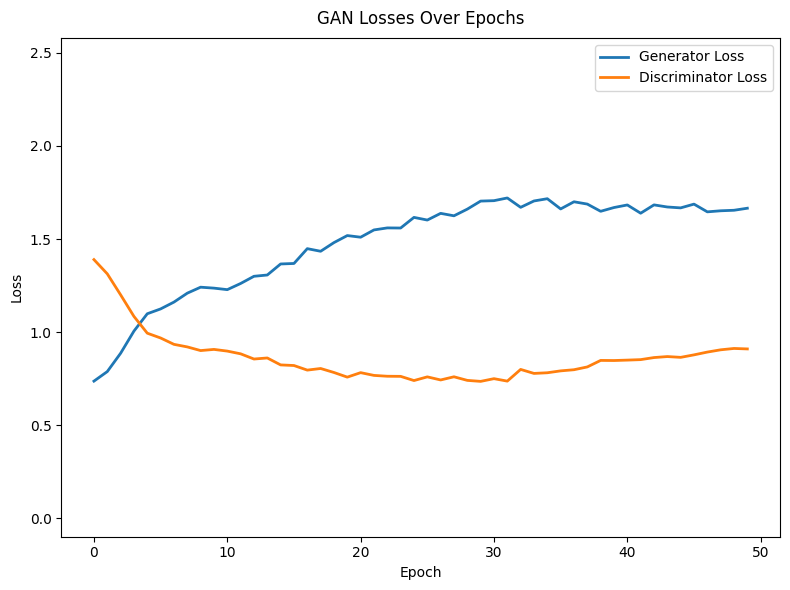

GAN Detection AUC: 1.0000
GAN Efficacy: Real AUC = 0.8980, Synth AUC = 0.3299, Ratio = 0.3674
Epoch [10/50] | G Loss: 1.2006 | D Loss: 0.9160
Epoch [20/50] | G Loss: 1.4603 | D Loss: 0.7934
Epoch [30/50] | G Loss: 1.6816 | D Loss: 0.7599
Epoch [40/50] | G Loss: 1.6451 | D Loss: 0.8386
Epoch [50/50] | G Loss: 1.4237 | D Loss: 1.0459


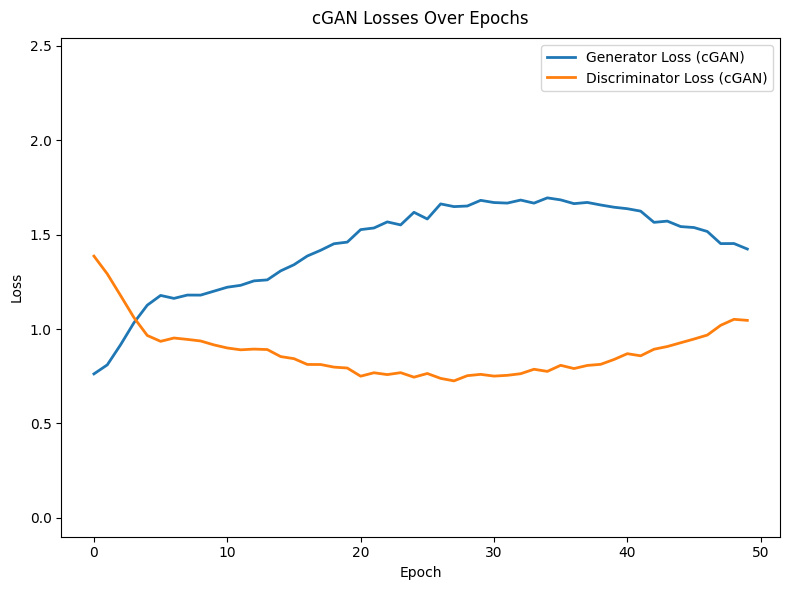

cGAN Detection AUC: 1.0000
cGAN Efficacy: Real AUC = 0.8980, Synth AUC = 0.8324, Ratio = 0.9270


In [4]:


# SET SEED
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = 'cuda' if torch.cuda.is_available() else 'cpu'


# TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = get_data_splits(random_seed=seed)


# TRAIN A STANDARD (UNCONDITIONAL) GAN
gan_lr = 0.00001
gan_noise_dim = 64
gan_hidden_dims = [128, 128]
gan_batch_size = 128
gan_dropout_rate = 0.3
gan_batch_norm = False
n_epochs = 50

G, D, G_losses, D_losses = train_gan(
    X_train=X_train,
    noise_dim=gan_noise_dim,
    batch_size=gan_batch_size,
    lr=gan_lr,
    n_epochs=n_epochs,
    hidden_dims=gan_hidden_dims,
    dropout_rate=gan_dropout_rate,
    batch_norm=gan_batch_norm,
    device=device
)


# PLOT GAN LOSSES
plt.figure(figsize=(8, 6))
plt.plot(range(n_epochs), G_losses, label='Generator Loss', linewidth=2)
plt.plot(range(n_epochs), D_losses, label='Discriminator Loss', linewidth=2)
plt.title('GAN Losses Over Epochs', fontsize=12, pad=10)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend(fontsize=10)

# Calculate appropriate y-axis limits
max_loss = max(max(G_losses), max(D_losses))
plt.ylim(-0.1, max_loss * 1.5)  # Extend y-axis range by 50%

# Make plot more compact
plt.tight_layout()
plt.show()


# GENERATE SYNTHETIC DATA AND EVALUATE
with torch.no_grad():
    z = torch.randn(len(X_train), gan_noise_dim).to(device)
    X_gan_synth = G(z).cpu().numpy()

y_gan_synth = np.random.choice(y_train, len(X_train))

det_auc_gan = detection_metric(X_train, X_gan_synth)
print(f"GAN Detection AUC: {det_auc_gan:.4f}")

auc_real_gan, auc_synth_gan, ratio_gan = efficacy_metric(
    X_train, y_train, X_test, y_test, X_gan_synth, y_gan_synth
)
print(f"GAN Efficacy: Real AUC = {auc_real_gan:.4f}, Synth AUC = {auc_synth_gan:.4f}, Ratio = {ratio_gan:.4f}")


# TRAIN A CONDITIONAL GAN (cGAN)
cgan_lr = 0.0001
cgan_noise_dim = 32
cgan_hidden_dims = [256, 256]
cgan_batch_size = 128
cgan_dropout_rate = 0.3
cgan_batch_norm = True

G_c, D_c, G_c_losses, D_c_losses = train_cgan(
    X_train=X_train,
    y_train=y_train,
    noise_dim=cgan_noise_dim,
    batch_size=cgan_batch_size,
    lr=cgan_lr,
    n_epochs=n_epochs,
    hidden_dims=cgan_hidden_dims,
    dropout_rate=cgan_dropout_rate,
    batch_norm=cgan_batch_norm,
    device=device
)


# PLOT cGAN LOSSES
plt.figure(figsize=(8, 6))
plt.plot(range(n_epochs), G_c_losses, label='Generator Loss (cGAN)', linewidth=2)
plt.plot(range(n_epochs), D_c_losses, label='Discriminator Loss (cGAN)', linewidth=2)
plt.title('cGAN Losses Over Epochs', fontsize=12, pad=10)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend(fontsize=10)

# Calculate appropriate y-axis limits
max_loss = max(max(G_c_losses), max(D_c_losses))
plt.ylim(-0.1, max_loss * 1.5)  # Extend y-axis range by 50%

# Make plot more compact
plt.tight_layout()
plt.show()


# 8) GENERATE SYNTHETIC DATA (cGAN) AND EVALUATE
with torch.no_grad():
    num_classes = len(np.unique(y_train))
    y_train_oh = np.eye(num_classes)[y_train]
    y_train_oh_torch = torch.FloatTensor(y_train_oh).to(device)

    z_cgan = torch.randn(len(X_train), cgan_noise_dim).to(device)
    X_cgan_synth = G_c(z_cgan, y_train_oh_torch).cpu().numpy()

y_cgan_synth = y_train.copy()

det_auc_cgan = detection_metric(X_train, X_cgan_synth)
print(f"cGAN Detection AUC: {det_auc_cgan:.4f}")

auc_real_cgan, auc_synth_cgan, ratio_cgan = efficacy_metric(
    X_train, y_train, X_test, y_test, X_cgan_synth, y_cgan_synth
)
print(f"cGAN Efficacy: Real AUC = {auc_real_cgan:.4f}, Synth AUC = {auc_synth_cgan:.4f}, Ratio = {ratio_cgan:.4f}")

Epoch [10/50] | G Loss: 1.2785 | D Loss: 0.9003
Epoch [20/50] | G Loss: 1.4269 | D Loss: 0.8272
Epoch [30/50] | G Loss: 1.6112 | D Loss: 0.7781
Epoch [40/50] | G Loss: 1.6721 | D Loss: 0.8331
Epoch [50/50] | G Loss: 1.6041 | D Loss: 0.9282


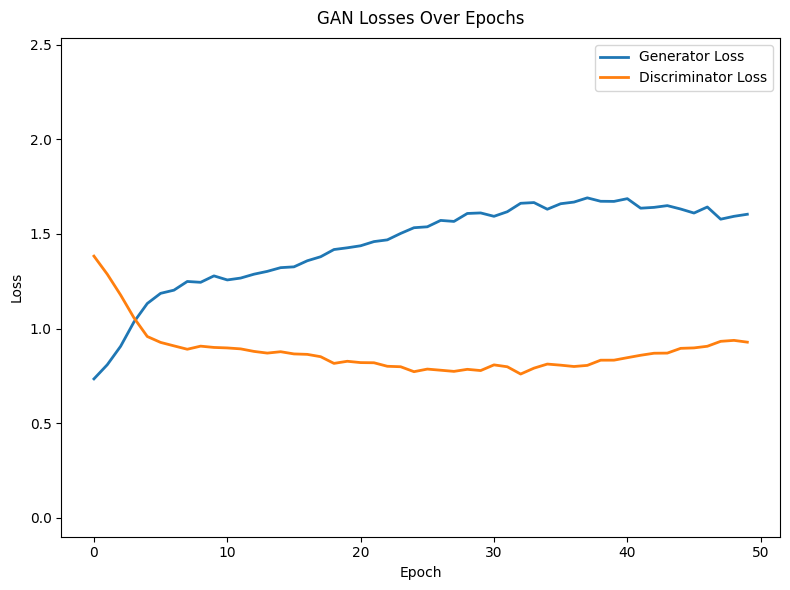

GAN Detection AUC: 1.0000
GAN Efficacy: Real AUC = 0.9101, Synth AUC = 0.5088, Ratio = 0.5590
Epoch [10/50] | G Loss: 1.2090 | D Loss: 0.9320
Epoch [20/50] | G Loss: 1.4155 | D Loss: 0.8069
Epoch [30/50] | G Loss: 1.6820 | D Loss: 0.7485
Epoch [40/50] | G Loss: 1.6716 | D Loss: 0.8211
Epoch [50/50] | G Loss: 1.5994 | D Loss: 0.9549


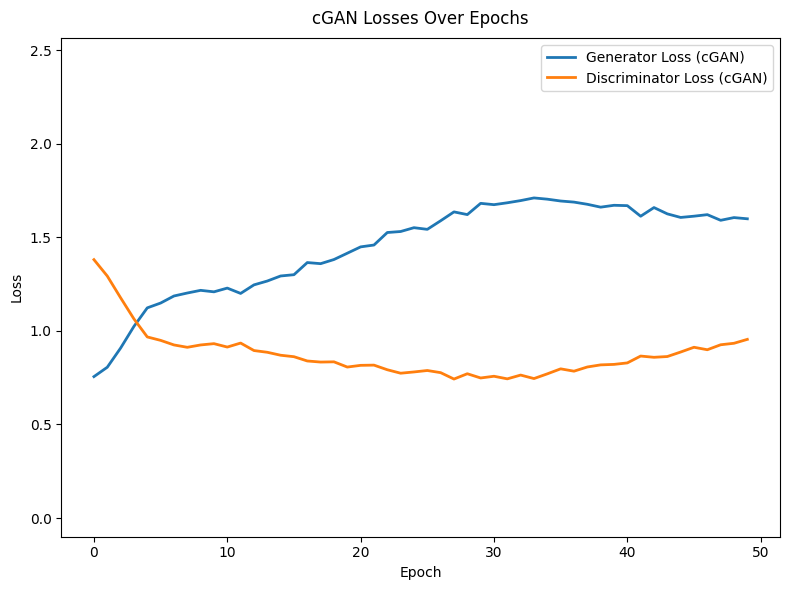

cGAN Detection AUC: 1.0000
cGAN Efficacy: Real AUC = 0.9101, Synth AUC = 0.8702, Ratio = 0.9562


In [ ]:

# SET SEED
seed = 86
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = 'cuda' if torch.cuda.is_available() else 'cpu'


# TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = get_data_splits(random_seed=seed)


# TRAIN A STANDARD (UNCONDITIONAL) GAN
gan_lr = 0.00001
gan_noise_dim = 64
gan_hidden_dims = [128, 128]
gan_batch_size = 128
gan_dropout_rate = 0.3
gan_batch_norm = False
n_epochs = 50

G, D, G_losses, D_losses = train_gan(
    X_train=X_train,
    noise_dim=gan_noise_dim,
    batch_size=gan_batch_size,
    lr=gan_lr,
    n_epochs=n_epochs,
    hidden_dims=gan_hidden_dims,
    dropout_rate=gan_dropout_rate,
    batch_norm=gan_batch_norm,
    device=device
)


# PLOT GAN LOSSES
plt.figure(figsize=(8, 6))
plt.plot(range(n_epochs), G_losses, label='Generator Loss', linewidth=2)
plt.plot(range(n_epochs), D_losses, label='Discriminator Loss', linewidth=2)
plt.title('GAN Losses Over Epochs', fontsize=12, pad=10)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend(fontsize=10)

# Calculate appropriate y-axis limits
max_loss = max(max(G_losses), max(D_losses))
plt.ylim(-0.1, max_loss * 1.5)  # Extend y-axis range by 50%

# Make plot more compact
plt.tight_layout()
plt.show()


# GENERATE SYNTHETIC DATA AND EVALUATE
with torch.no_grad():
    z = torch.randn(len(X_train), gan_noise_dim).to(device)
    X_gan_synth = G(z).cpu().numpy()

y_gan_synth = np.random.choice(y_train, len(X_train))

det_auc_gan = detection_metric(X_train, X_gan_synth)
print(f"GAN Detection AUC: {det_auc_gan:.4f}")

auc_real_gan, auc_synth_gan, ratio_gan = efficacy_metric(
    X_train, y_train, X_test, y_test, X_gan_synth, y_gan_synth
)
print(f"GAN Efficacy: Real AUC = {auc_real_gan:.4f}, Synth AUC = {auc_synth_gan:.4f}, Ratio = {ratio_gan:.4f}")


# TRAIN A CONDITIONAL GAN (cGAN)
cgan_lr = 0.0001
cgan_noise_dim = 32
cgan_hidden_dims = [256, 256]
cgan_batch_size = 128
cgan_dropout_rate = 0.3
cgan_batch_norm = True

G_c, D_c, G_c_losses, D_c_losses = train_cgan(
    X_train=X_train,
    y_train=y_train,
    noise_dim=cgan_noise_dim,
    batch_size=cgan_batch_size,
    lr=cgan_lr,
    n_epochs=n_epochs,
    hidden_dims=cgan_hidden_dims,
    dropout_rate=cgan_dropout_rate,
    batch_norm=cgan_batch_norm,
    device=device
)


# 7) PLOT cGAN LOSSES
plt.figure(figsize=(8, 6))
plt.plot(range(n_epochs), G_c_losses, label='Generator Loss (cGAN)', linewidth=2)
plt.plot(range(n_epochs), D_c_losses, label='Discriminator Loss (cGAN)', linewidth=2)
plt.title('cGAN Losses Over Epochs', fontsize=12, pad=10)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend(fontsize=10)

# Calculate appropriate y-axis limits
max_loss = max(max(G_c_losses), max(D_c_losses))
plt.ylim(-0.1, max_loss * 1.5)  # Extend y-axis range by 50%

# Make plot more compact
plt.tight_layout()
plt.show()


# GENERATE SYNTHETIC DATA (cGAN) AND EVALUATE
with torch.no_grad():
    num_classes = len(np.unique(y_train))
    y_train_oh = np.eye(num_classes)[y_train]
    y_train_oh_torch = torch.FloatTensor(y_train_oh).to(device)

    z_cgan = torch.randn(len(X_train), cgan_noise_dim).to(device)
    X_cgan_synth = G_c(z_cgan, y_train_oh_torch).cpu().numpy()

y_cgan_synth = y_train.copy()

det_auc_cgan = detection_metric(X_train, X_cgan_synth)
print(f"cGAN Detection AUC: {det_auc_cgan:.4f}")

auc_real_cgan, auc_synth_cgan, ratio_cgan = efficacy_metric(
    X_train, y_train, X_test, y_test, X_cgan_synth, y_cgan_synth
)
print(f"cGAN Efficacy: Real AUC = {auc_real_cgan:.4f}, Synth AUC = {auc_synth_cgan:.4f}, Ratio = {ratio_cgan:.4f}")

## analyze distributions

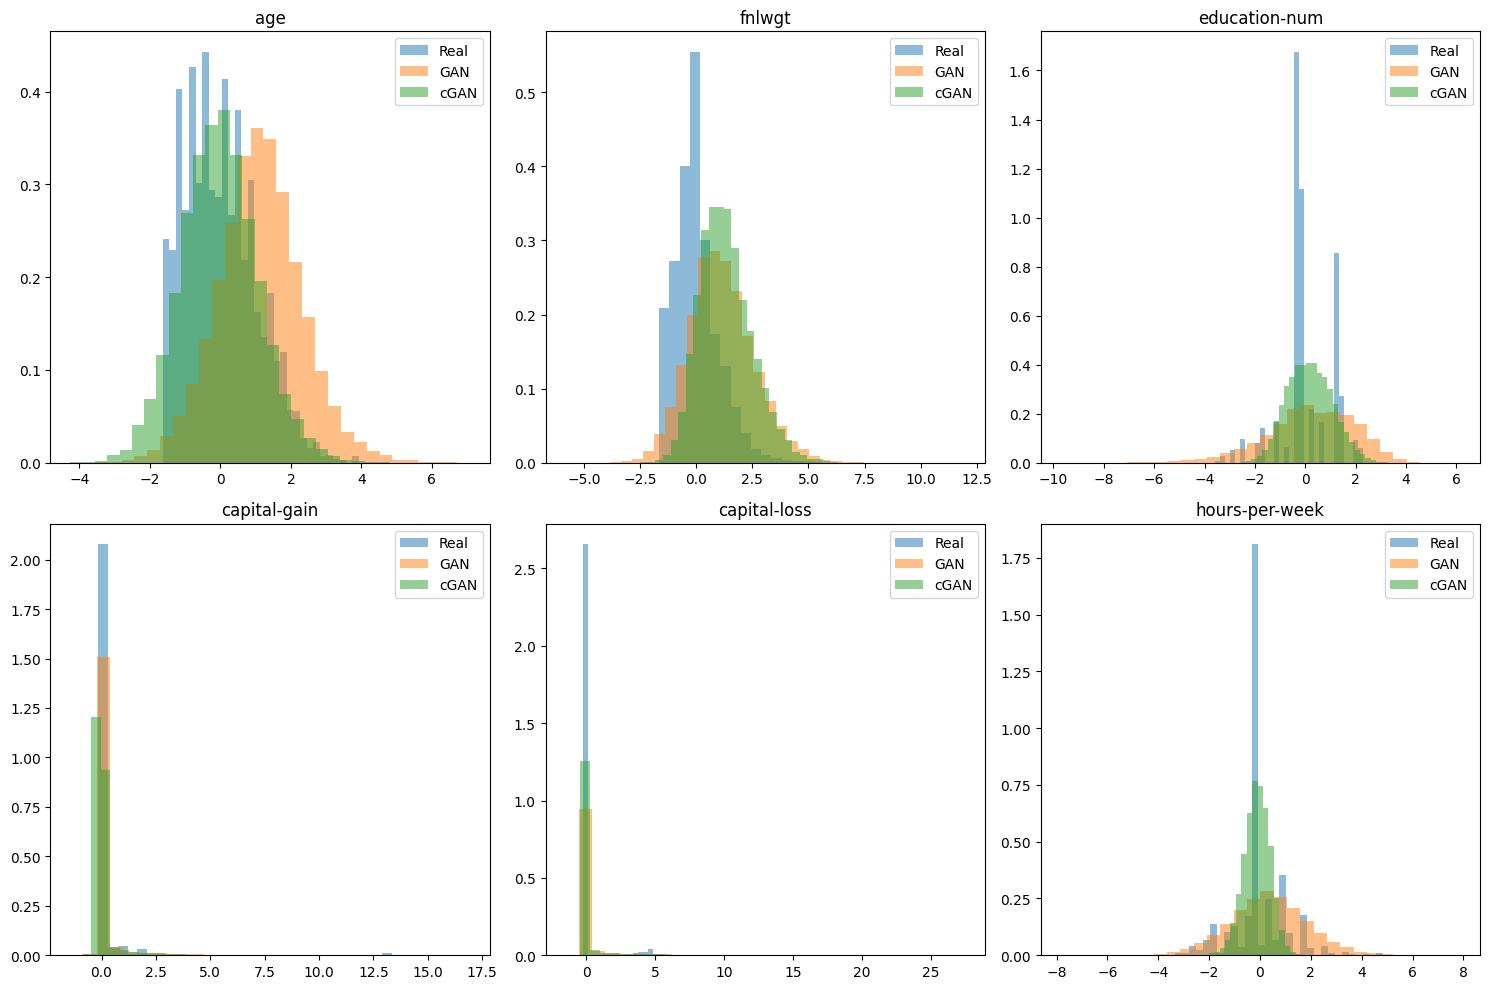

In [34]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def generate_synthetic_data(G, G_c, X_train, y_train, noise_dim, device):
    """Generate synthetic data using both GAN and cGAN"""
    # Generate data using standard GAN
    with torch.no_grad():
        z = torch.randn(len(X_train), noise_dim).to(device)
        X_gan_synth = G(z).cpu().numpy()

    # Generate data using cGAN
    with torch.no_grad():
        num_classes = len(np.unique(y_train))
        y_train_oh = np.eye(num_classes)[y_train]
        y_train_oh_torch = torch.FloatTensor(y_train_oh).to(device)

        z_cgan = torch.randn(len(X_train), noise_dim).to(device)
        X_cgan_synth = G_c(z_cgan, y_train_oh_torch).cpu().numpy()

    return X_gan_synth, X_cgan_synth

def plot_feature_distributions(X_real, X_synth_gan, X_synth_cgan, feature_names, num_features=6):
    """Plot histograms comparing real and synthetic distributions for selected features"""
    plt.figure(figsize=(15, 10))

    # Select a subset of features to visualize
    for idx, feature in enumerate(feature_names[:num_features]):
        plt.subplot(2, 3, idx + 1)

        # Plot histograms
        plt.hist(X_real[:, idx], bins=30, alpha=0.5, label='Real', density=True)
        plt.hist(X_synth_gan[:, idx], bins=30, alpha=0.5, label='GAN', density=True)
        plt.hist(X_synth_cgan[:, idx], bins=30, alpha=0.5, label='cGAN', density=True)

        plt.title(f'{feature}')
        plt.legend()

    plt.tight_layout()
    plt.show()

def plot_correlation_matrices(X_real, X_synth_gan, X_synth_cgan, feature_names):
    """Plot correlation matrices for real and synthetic data"""
    # Calculate correlation matrices
    corr_real = pd.DataFrame(np.corrcoef(X_real.T), columns=feature_names, index=feature_names)
    corr_gan = pd.DataFrame(np.corrcoef(X_synth_gan.T), columns=feature_names, index=feature_names)
    corr_cgan = pd.DataFrame(np.corrcoef(X_synth_cgan.T), columns=feature_names, index=feature_names)

    # Create a figure with three subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

    # Plot correlation matrices
    sns.heatmap(corr_real, ax=ax1, cmap='coolwarm', vmin=-1, vmax=1,
                xticklabels=True, yticklabels=True)
    ax1.set_title('Real Data Correlations')
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
    plt.setp(ax1.get_yticklabels(), rotation=0)

    sns.heatmap(corr_gan, ax=ax2, cmap='coolwarm', vmin=-1, vmax=1,
                xticklabels=True, yticklabels=True)
    ax2.set_title('GAN Synthetic Data Correlations')
    plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
    plt.setp(ax2.get_yticklabels(), rotation=0)

    sns.heatmap(corr_cgan, ax=ax3, cmap='coolwarm', vmin=-1, vmax=1,
                xticklabels=True, yticklabels=True)
    ax3.set_title('cGAN Synthetic Data Correlations')
    plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')
    plt.setp(ax3.get_yticklabels(), rotation=0)

    plt.tight_layout()
    plt.show()

def compute_statistics(X_real, X_synth_gan, X_synth_cgan, feature_names):
    """Compute basic statistical measures for each feature"""
    stats = []

    for idx, feature in enumerate(feature_names):
        # Compute mean and std differences
        mean_diff_gan = abs(np.mean(X_real[:, idx]) - np.mean(X_synth_gan[:, idx]))
        mean_diff_cgan = abs(np.mean(X_real[:, idx]) - np.mean(X_synth_cgan[:, idx]))

        std_diff_gan = abs(np.std(X_real[:, idx]) - np.std(X_synth_gan[:, idx]))
        std_diff_cgan = abs(np.std(X_real[:, idx]) - np.std(X_synth_cgan[:, idx]))

        stats.append({
            'Feature': feature,
            'Mean_Diff_GAN': mean_diff_gan,
            'Mean_Diff_cGAN': mean_diff_cgan,
            'Std_Diff_GAN': std_diff_gan,
            'Std_Diff_cGAN': std_diff_cgan
        })

    return pd.DataFrame(stats)

# Generate synthetic data
X_gan_synth, X_cgan_synth = generate_synthetic_data(G, G_c, X_train, y_train, gan_noise_dim, device)

# Plot feature distributions
plot_feature_distributions(X_train, X_gan_synth, X_cgan_synth, feature_names)



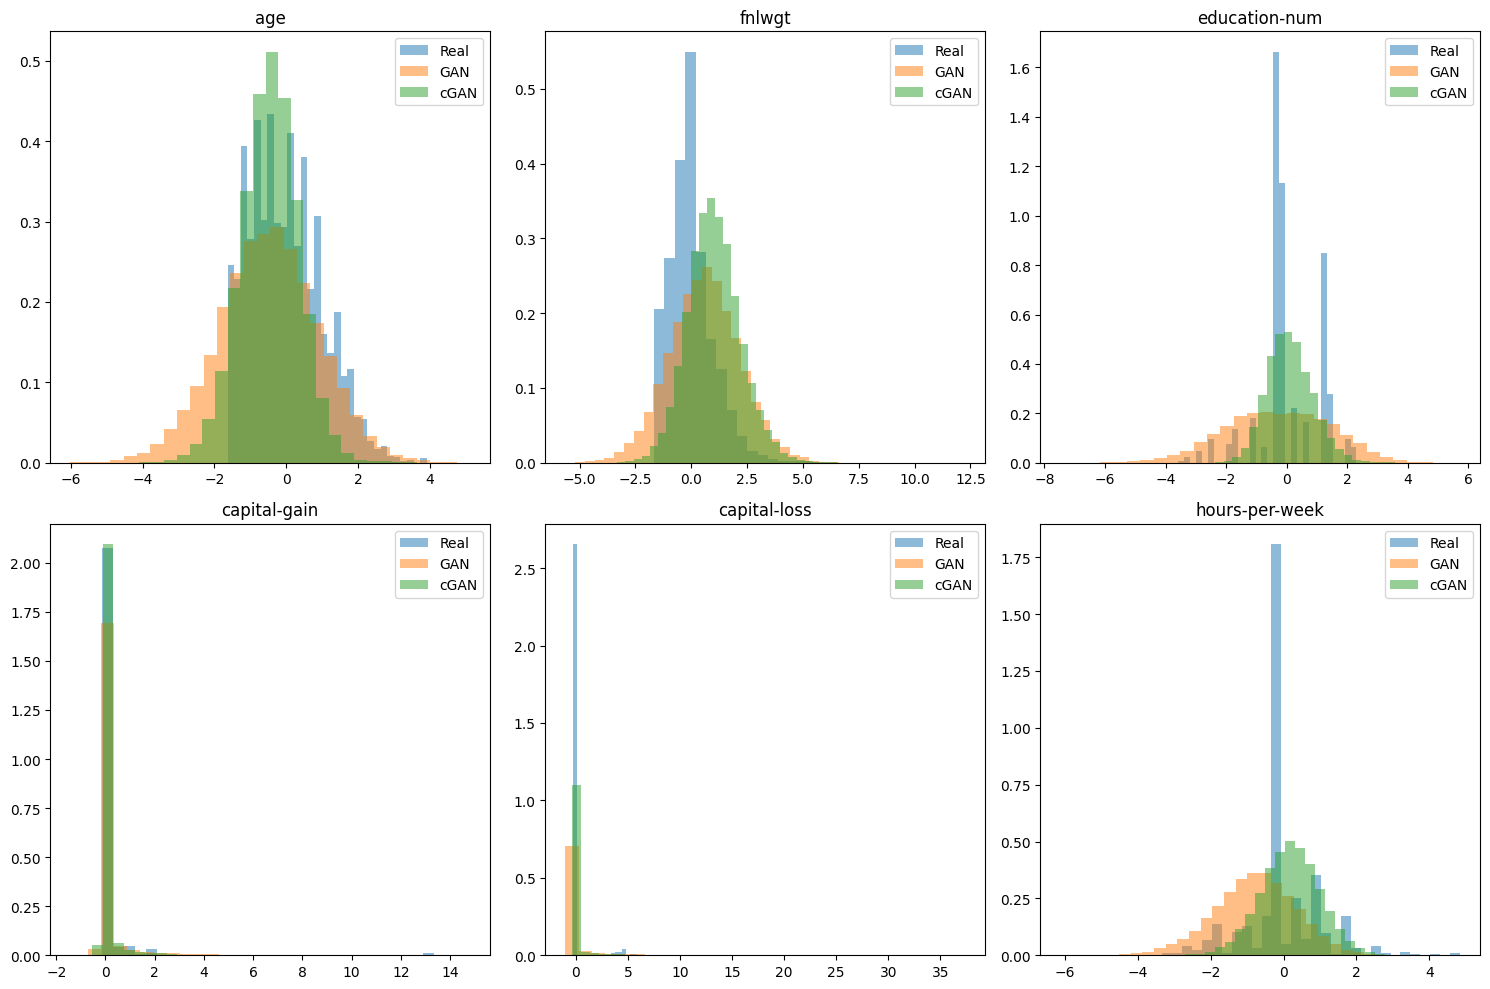

In [36]:
# seed=54

X_gan_synth, X_cgan_synth = generate_synthetic_data(G, G_c, X_train, y_train, gan_noise_dim, device)

# Plot feature distributions
plot_feature_distributions(X_train, X_gan_synth, X_cgan_synth, feature_names)

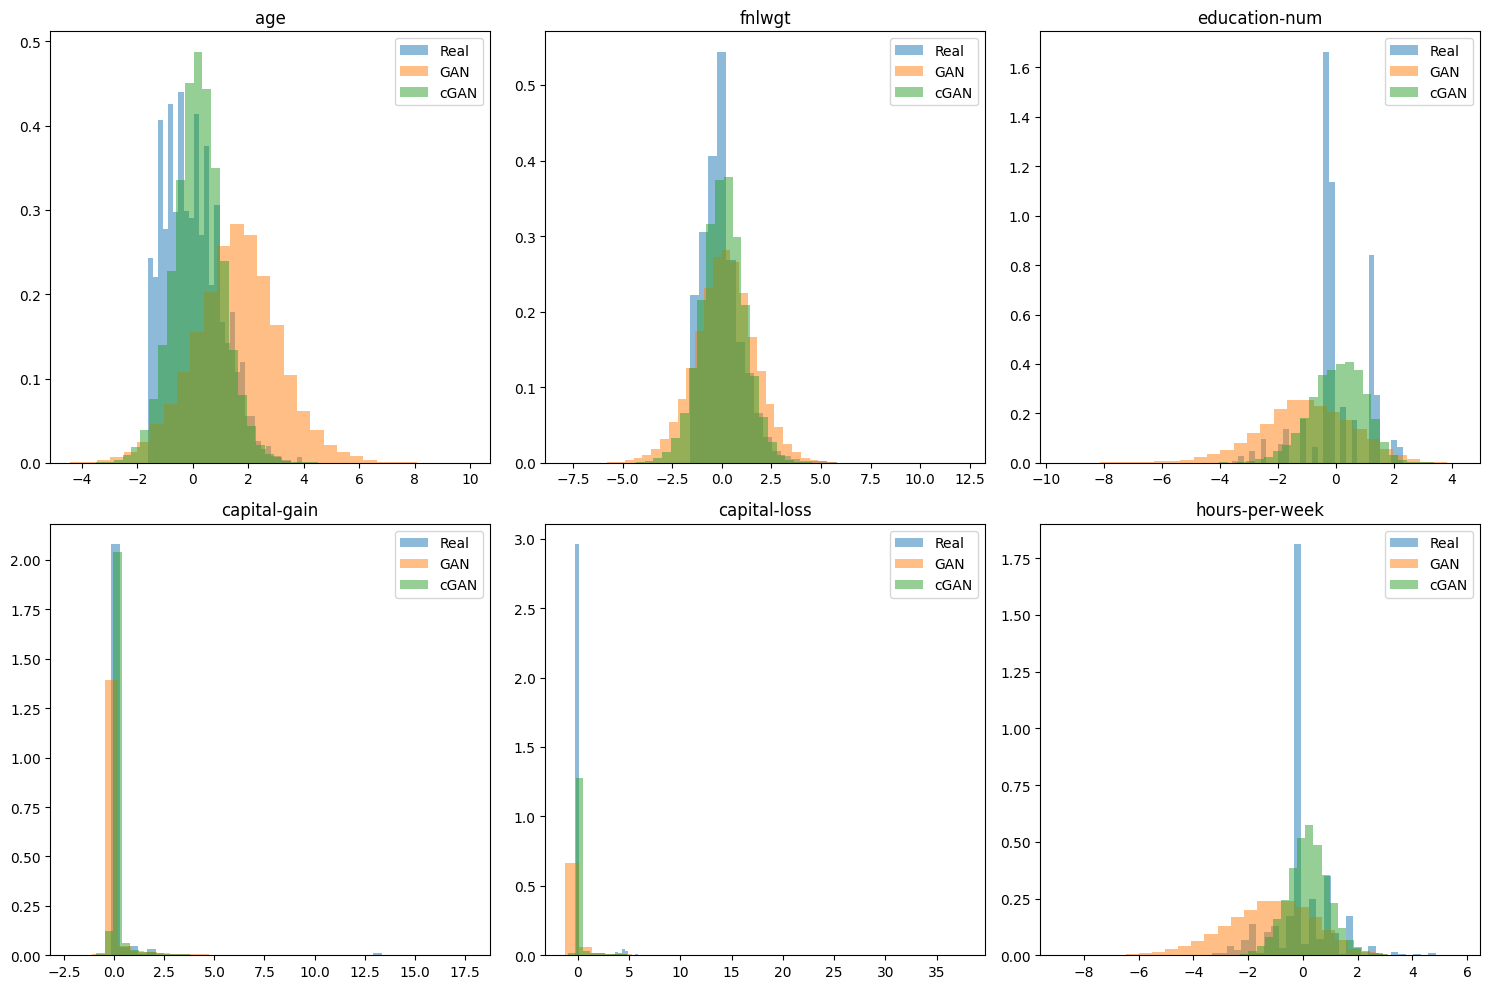

In [38]:
# seed=86
X_gan_synth, X_cgan_synth = generate_synthetic_data(G, G_c, X_train, y_train, gan_noise_dim, device)

# Plot feature distributions
plot_feature_distributions(X_train, X_gan_synth, X_cgan_synth, feature_names)

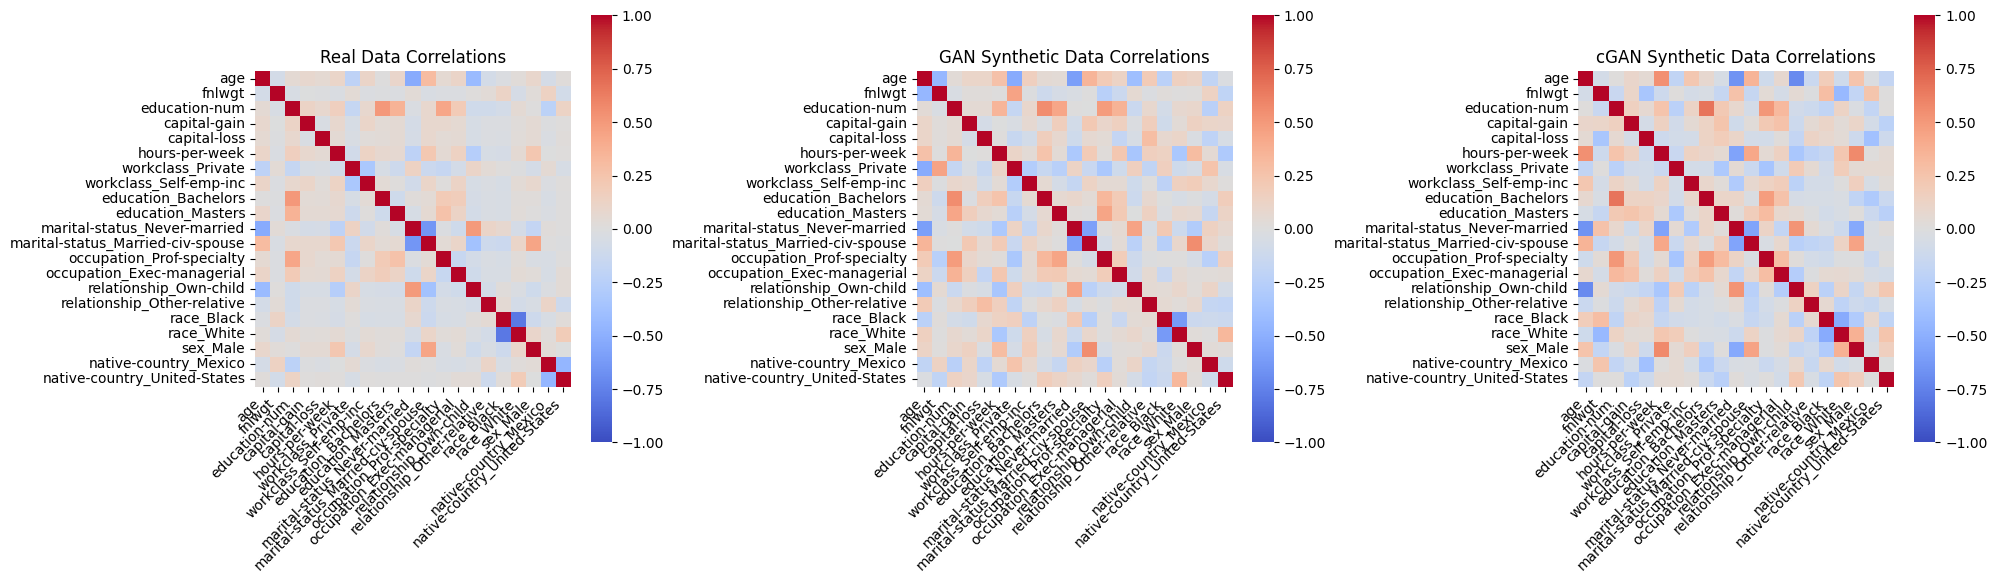


Selected Features for Correlation Analysis:

Continuous features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Selected categorical features by group:
workclass: ['workclass_Private', 'workclass_Self-emp-inc']
education: ['education_Bachelors', 'education_Masters']
marital-status: ['marital-status_Never-married', 'marital-status_Married-civ-spouse']
occupation: ['occupation_Prof-specialty', 'occupation_Exec-managerial']
relationship: ['relationship_Own-child', 'relationship_Other-relative']
race: ['race_Black', 'race_White']
sex: ['sex_Male']
native-country: ['native-country_Mexico', 'native-country_United-States']


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def select_important_features(X, feature_names, continuous_cols, cat_group_dict, n_cat_features=2):
    """
    Select continuous features and the two most important categorical features from each group
    """
    # Convert to DataFrame for easier manipulation
    df = pd.DataFrame(X, columns=feature_names)

    # Start with continuous columns
    selected_features = continuous_cols.copy()

    # For each categorical group, select top two features
    for cat_name, (start, end) in cat_group_dict.items():
        cat_cols = feature_names[start:end]

        # Calculate average absolute correlation with continuous features
        corr_matrix = df[cat_cols + continuous_cols].corr()
        avg_corr = abs(corr_matrix.iloc[:len(cat_cols), len(cat_cols):]).mean(axis=1)

        # Select the top two columns from this category
        top_cols = avg_corr.nlargest(2).index.tolist()
        selected_features.extend(top_cols)

    return selected_features

def plot_focused_correlation_matrices(X_real, X_synth_gan, X_synth_cgan, feature_names,
                                   continuous_cols, cat_group_dict):
    """Plot correlation matrices for selected features"""
    # Select important features
    selected_features = select_important_features(X_real, feature_names,
                                                continuous_cols, cat_group_dict,
                                                n_cat_features=2)

    # Create DataFrames with selected features
    df_real = pd.DataFrame(X_real, columns=feature_names)[selected_features]
    df_gan = pd.DataFrame(X_synth_gan, columns=feature_names)[selected_features]
    df_cgan = pd.DataFrame(X_synth_cgan, columns=feature_names)[selected_features]

    # Calculate correlation matrices
    corr_real = df_real.corr()
    corr_gan = df_gan.corr()
    corr_cgan = df_cgan.corr()

    # Create a figure with three subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

    # Plot correlation matrices
    sns.heatmap(corr_real, ax=ax1, cmap='coolwarm', vmin=-1, vmax=1,
                xticklabels=True, yticklabels=True, square=True)
    ax1.set_title('Real Data Correlations')
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
    plt.setp(ax1.get_yticklabels(), rotation=0)

    sns.heatmap(corr_gan, ax=ax2, cmap='coolwarm', vmin=-1, vmax=1,
                xticklabels=True, yticklabels=True, square=True)
    ax2.set_title('GAN Synthetic Data Correlations')
    plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
    plt.setp(ax2.get_yticklabels(), rotation=0)

    sns.heatmap(corr_cgan, ax=ax3, cmap='coolwarm', vmin=-1, vmax=1,
                xticklabels=True, yticklabels=True, square=True)
    ax3.set_title('cGAN Synthetic Data Correlations')
    plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')
    plt.setp(ax3.get_yticklabels(), rotation=0)

    plt.tight_layout()
    plt.show()

    return selected_features

# seed = 54
# Define continuous columns
continuous_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

# Generate synthetic data
X_gan_synth, X_cgan_synth = generate_synthetic_data(G, G_c, X_train, y_train, gan_noise_dim, device)

# Plot focused correlation matrices
selected_features = plot_focused_correlation_matrices(X_train, X_gan_synth, X_cgan_synth,
                                                    feature_names, continuous_cols, cat_group_dict)

# Print selected features for reference
print("\nSelected Features for Correlation Analysis:")
print("\nContinuous features:", [f for f in selected_features if f in continuous_cols])
print("\nSelected categorical features by group:")
for cat_name, (start, end) in cat_group_dict.items():
    cat_features = [f for f in selected_features if f in feature_names[start:end]]
    if cat_features:
        print(f"{cat_name}:", cat_features)

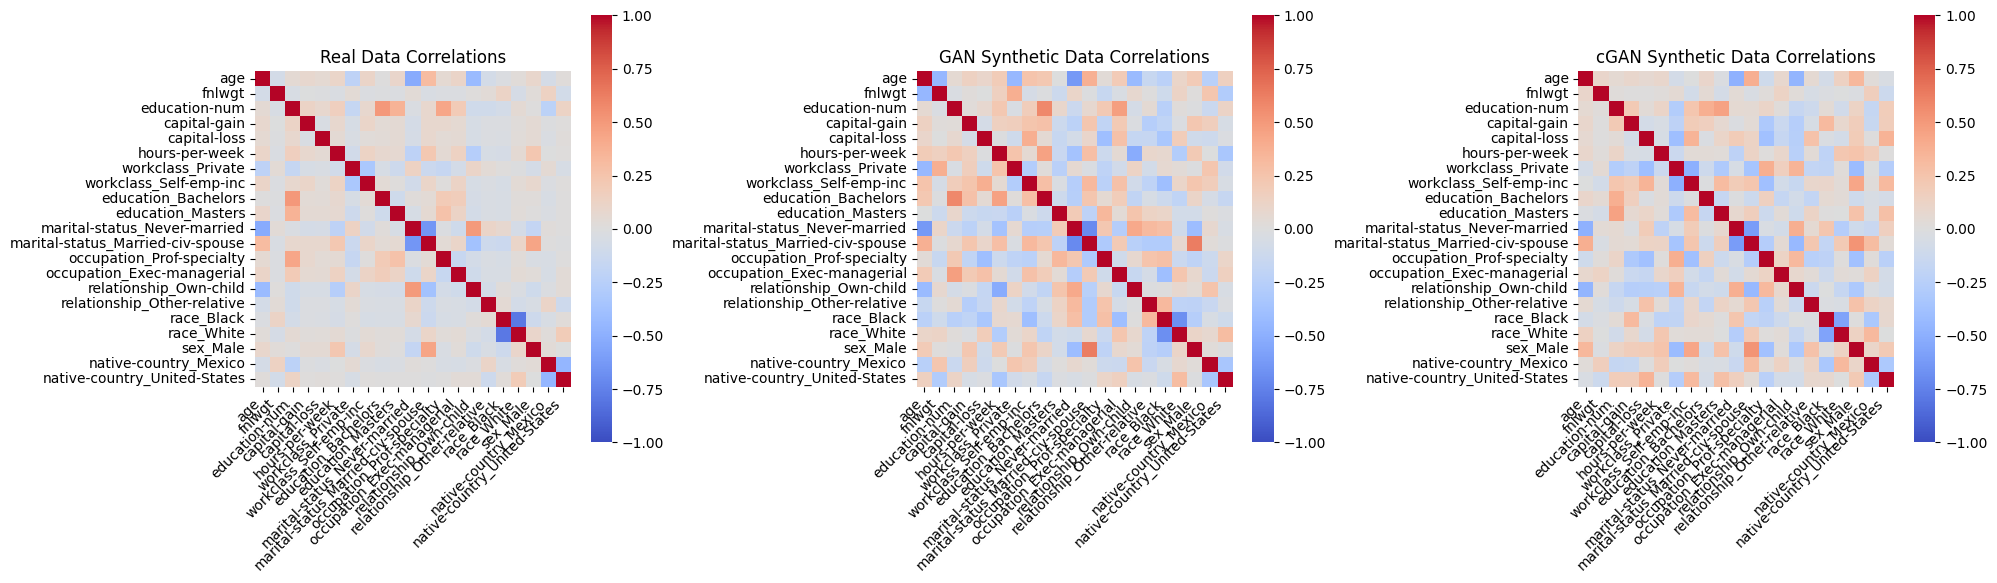


Selected Features for Correlation Analysis:

Continuous features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Selected categorical features by group:
workclass: ['workclass_Private', 'workclass_Self-emp-inc']
education: ['education_Bachelors', 'education_Masters']
marital-status: ['marital-status_Never-married', 'marital-status_Married-civ-spouse']
occupation: ['occupation_Prof-specialty', 'occupation_Exec-managerial']
relationship: ['relationship_Own-child', 'relationship_Other-relative']
race: ['race_Black', 'race_White']
sex: ['sex_Male']
native-country: ['native-country_Mexico', 'native-country_United-States']


In [41]:
# seed=0

# Define continuous columns
continuous_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

# Generate synthetic data
X_gan_synth, X_cgan_synth = generate_synthetic_data(G, G_c, X_train, y_train, gan_noise_dim, device)

# Plot focused correlation matrices
selected_features = plot_focused_correlation_matrices(X_train, X_gan_synth, X_cgan_synth,
                                                    feature_names, continuous_cols, cat_group_dict)

# Print selected features for reference
print("\nSelected Features for Correlation Analysis:")
print("\nContinuous features:", [f for f in selected_features if f in continuous_cols])
print("\nSelected categorical features by group:")
for cat_name, (start, end) in cat_group_dict.items():
    cat_features = [f for f in selected_features if f in feature_names[start:end]]
    if cat_features:
        print(f"{cat_name}:", cat_features)

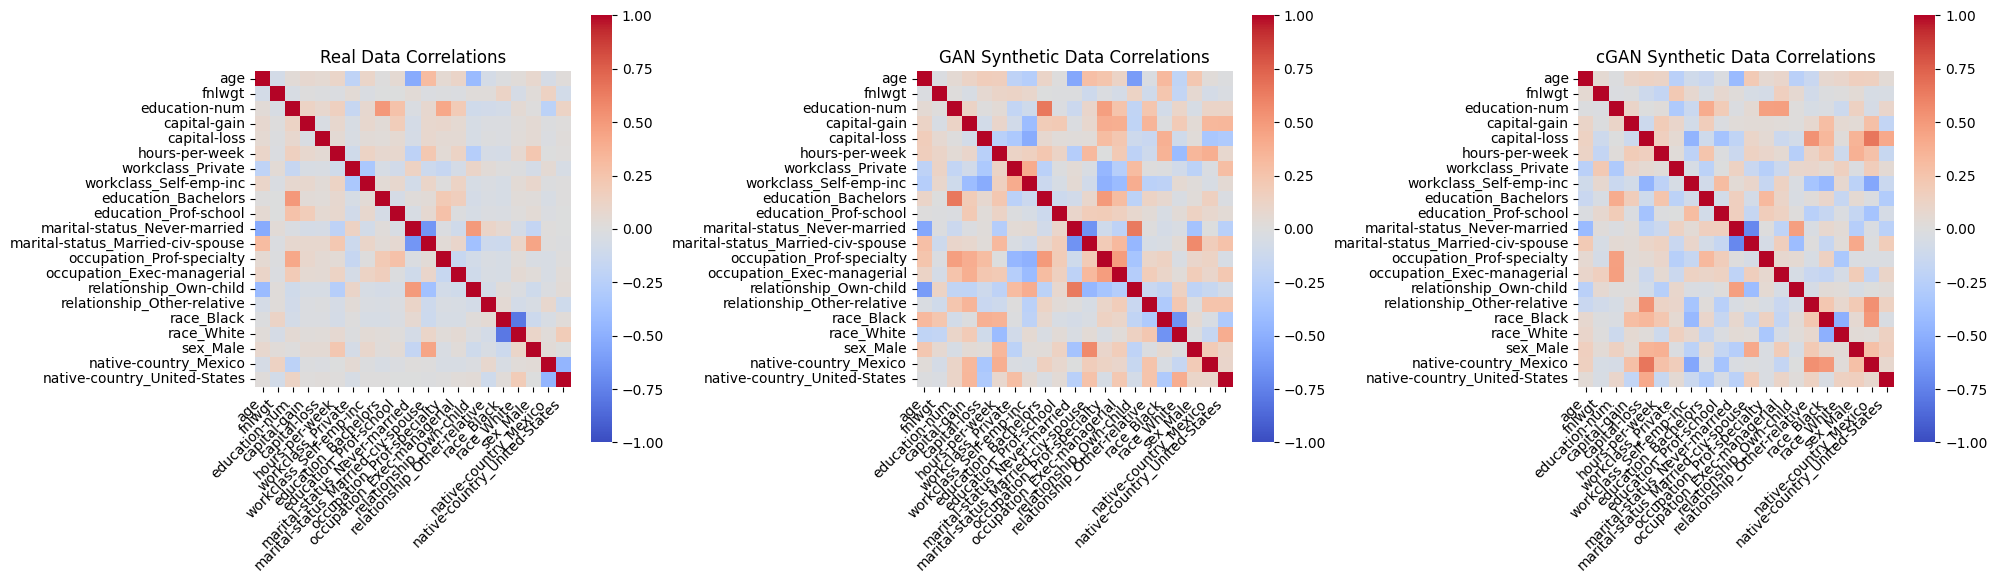


Selected Features for Correlation Analysis:

Continuous features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Selected categorical features by group:
workclass: ['workclass_Private', 'workclass_Self-emp-inc']
education: ['education_Bachelors', 'education_Prof-school']
marital-status: ['marital-status_Never-married', 'marital-status_Married-civ-spouse']
occupation: ['occupation_Prof-specialty', 'occupation_Exec-managerial']
relationship: ['relationship_Own-child', 'relationship_Other-relative']
race: ['race_Black', 'race_White']
sex: ['sex_Male']
native-country: ['native-country_Mexico', 'native-country_United-States']


In [39]:
# seed=86

# Define continuous columns
continuous_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

# Generate synthetic data
X_gan_synth, X_cgan_synth = generate_synthetic_data(G, G_c, X_train, y_train, gan_noise_dim, device)

# Plot focused correlation matrices
selected_features = plot_focused_correlation_matrices(X_train, X_gan_synth, X_cgan_synth,
                                                    feature_names, continuous_cols, cat_group_dict)

# Print selected features for reference
print("\nSelected Features for Correlation Analysis:")
print("\nContinuous features:", [f for f in selected_features if f in continuous_cols])
print("\nSelected categorical features by group:")
for cat_name, (start, end) in cat_group_dict.items():
    cat_features = [f for f in selected_features if f in feature_names[start:end]]
    if cat_features:
        print(f"{cat_name}:", cat_features)